# Phase 5 — ITS Diagnostics (PRELIMINARY)

**Stage:** baseline interrupted time series + residual diagnostics + growth companion
+ the pre-specified B1 `Transition_t` robustness. **Nothing else.**

> **Explicitly NOT in this notebook:** forecasting, volatility inference, control
> estimation, the full robustness matrix, alternative break dates, Bai–Perron,
> ARMA-errors, or any model selection. Those belong to Phase 6 and later.

> **The specification is LOCKED** (`08_report/research_design_memo.md`; Decision Log
> D-001…D-003). This notebook *implements* it and *diagnoses* the fit. It does not
> revise it. Results are preliminary and are written to separate `ITS_prelim_*` files.

**Units:** `g = 100·Δln(Y)` is in **log-growth points (lgp)** — percentage points of log
change, **not** percentage growth.

In [1]:
import warnings; warnings.filterwarnings("ignore")
import pandas as pd, numpy as np
import its_core as I
pd.set_option("display.width", 230); pd.set_option("display.max_columns", 80)
df = I.load_panel()
print("panel:", df.shape)
print("locked D_s:", I.D_S)
print("locked COVID block (levels):", I.COVID_MONTHS)
print("locked COVID months (differenced):", I.COVID_MONTHS_DIFF)
print("locked B1 Transition window:", I.TRANSITION)
print("reference month for FE: April | HAC lags:", I.HAC_LAGS)

# inline display of figures saved to ../07_figures (same files, no duplicates)
from IPython.display import Image, display
def show(figs):
    if figs is None: return
    if isinstance(figs, str): figs = [figs]
    for f in figs:
        if f: display(Image(filename=f"../07_figures/{f}"))

panel: (672, 17)
locked D_s: {'B1_MOBILE': '2020-08', 'B2_PHARMA': '2022-04', 'B3_AC': '2022-04', 'B4_TEXTILE': '2024-04'}
locked COVID block (levels): ['2020-04', '2020-05', '2020-06']
locked COVID months (differenced): ['2020-04', '2020-05', '2020-06', '2020-07']
locked B1 Transition window: ('2022-01', '2022-04')
reference month for FE: April | HAC lags: (3, 12)


## 1. Construct the exact locked design matrix

```
ln(Y_t) = b0 + b1*T + b2*Post + b3*TimeAfter + sum gamma_m*Month_m + delta*Covid + eps
    T         = 1..96, April 2018 = 1
    Post      = 1{T >= T_Ds}
    TimeAfter = max(0, T - T_Ds)     <-- NOT +1, so b2 stays a clean level shift
    Covid     = 1{Apr, May, Jun 2020}
    Month     = 11 dummies, APRIL omitted
```
The assertions below confirm the matrix matches the lock before anything is fitted.

In [2]:
for b in I.TREATED:
    s = I.design(df, b, transition=(b == "B1_MOBILE"))
    ds = pd.Timestamp(I.D_S[b] + "-01")
    assert s.loc[ds, "Post"] == 1 and s.loc[ds - pd.DateOffset(months=1), "Post"] == 0
    assert s.loc[ds, "TimeAfter"] == 0 and s.loc[ds + pd.DateOffset(months=1), "TimeAfter"] == 1
    assert s.loc[ds, "Break"] == 1 and s["Break"].sum() == 1
    assert s["Covid"].sum() == 3 and len(s) == 96
    assert "M04" not in s.columns          # April is the omitted reference
    print(f"{b:11s} T_Ds={s.attrs['t_ds']:3d}  n={len(s)}  design matrix OK")

B1_MOBILE   T_Ds= 29  n=96  design matrix OK
B2_PHARMA   T_Ds= 49  n=96  design matrix OK
B3_AC       T_Ds= 49  n=96  design matrix OK
B4_TEXTILE  T_Ds= 73  n=96  design matrix OK


## 2. Fit the baseline ITS — β₁, β₂, β₃ with HAC(3) and HAC(12)

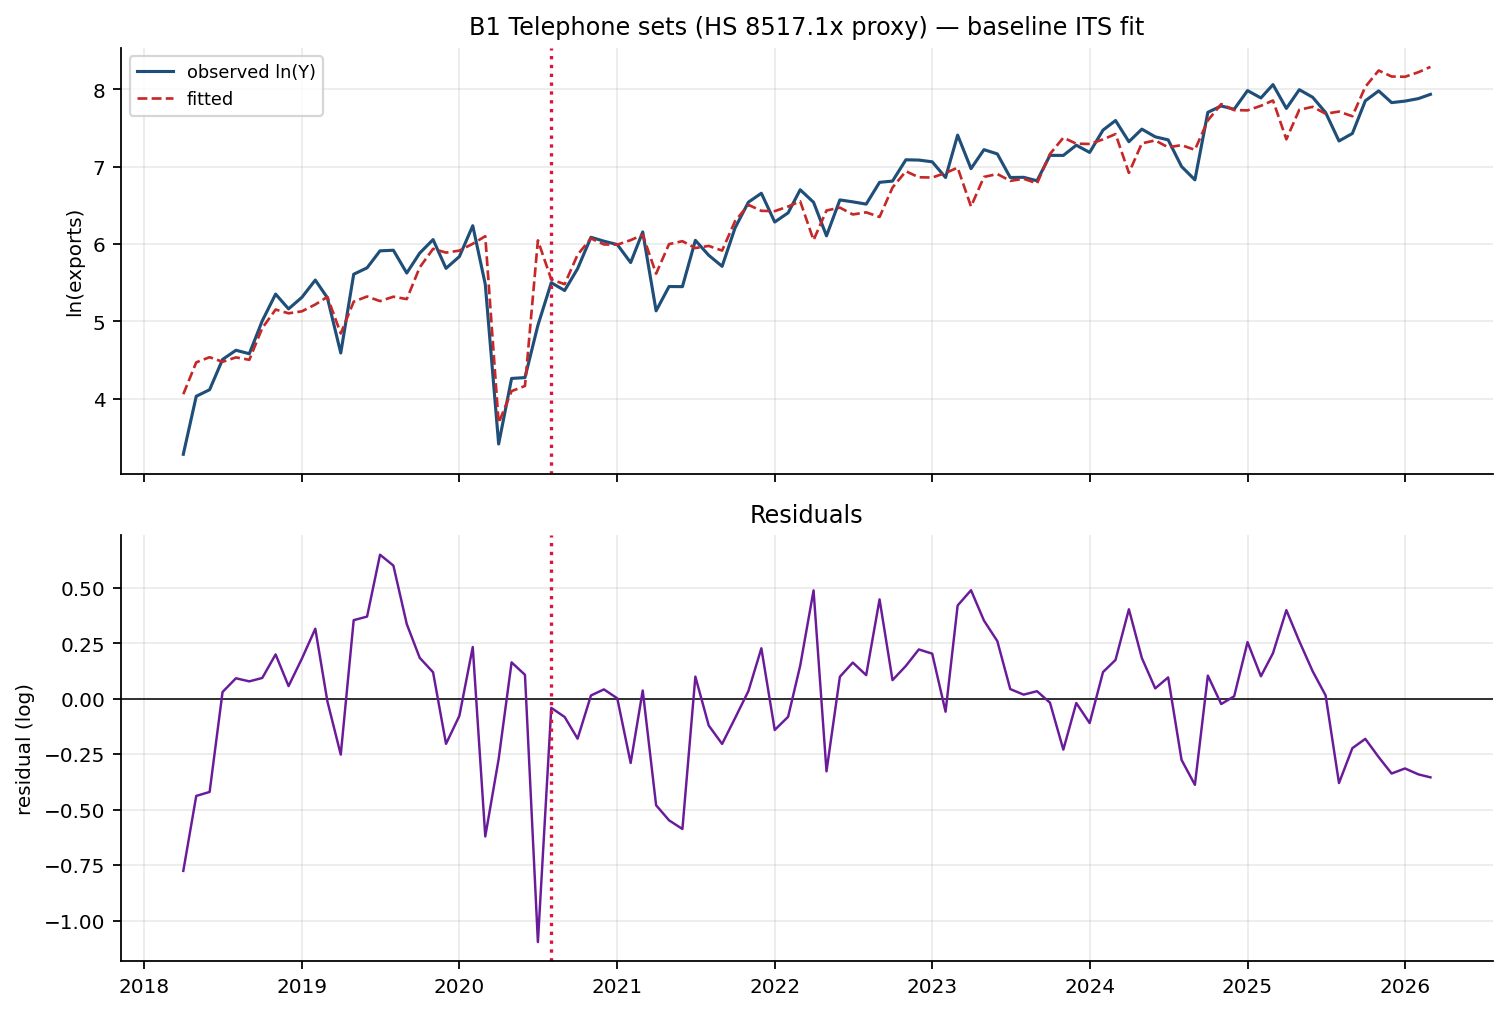

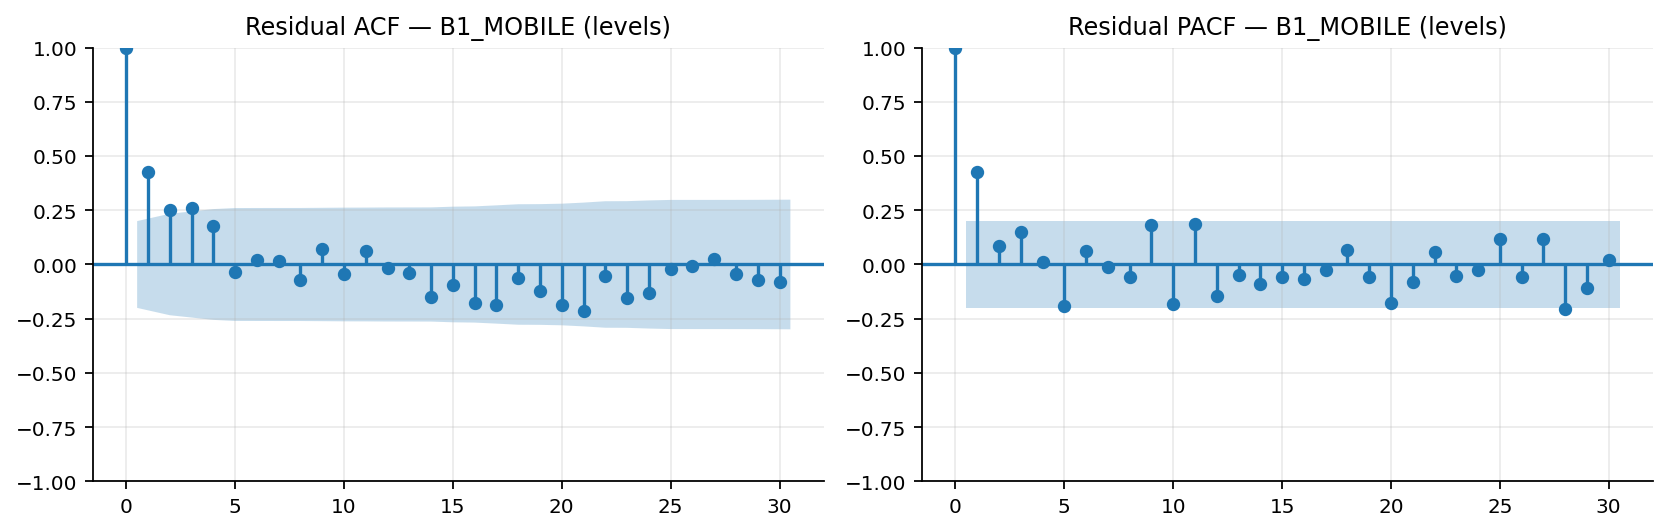

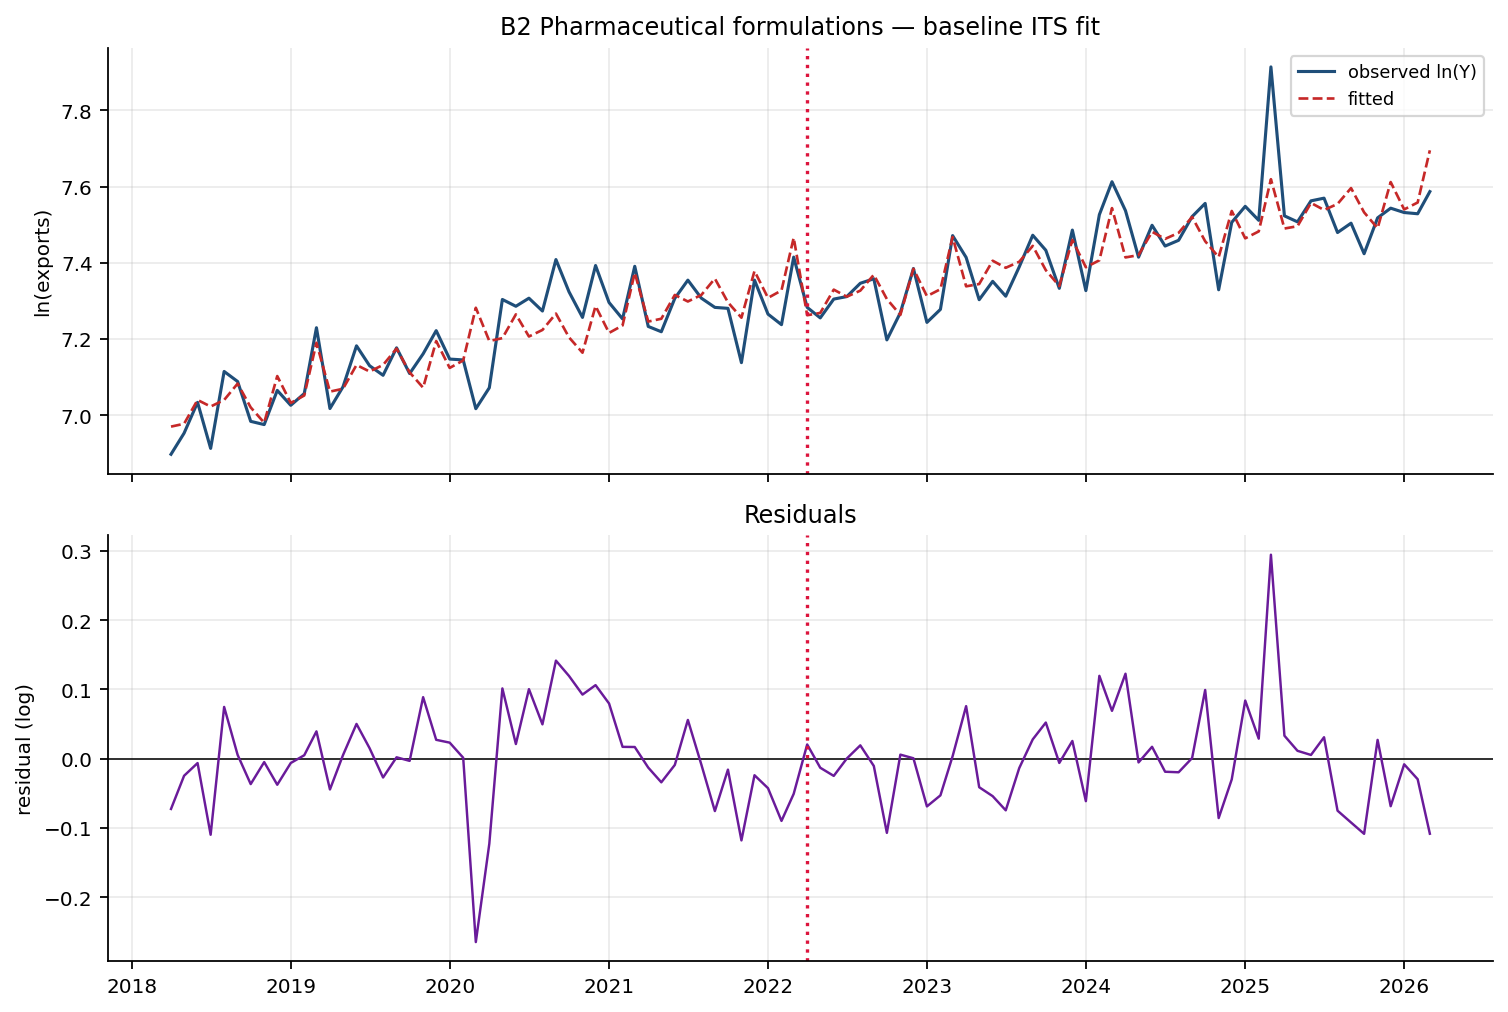

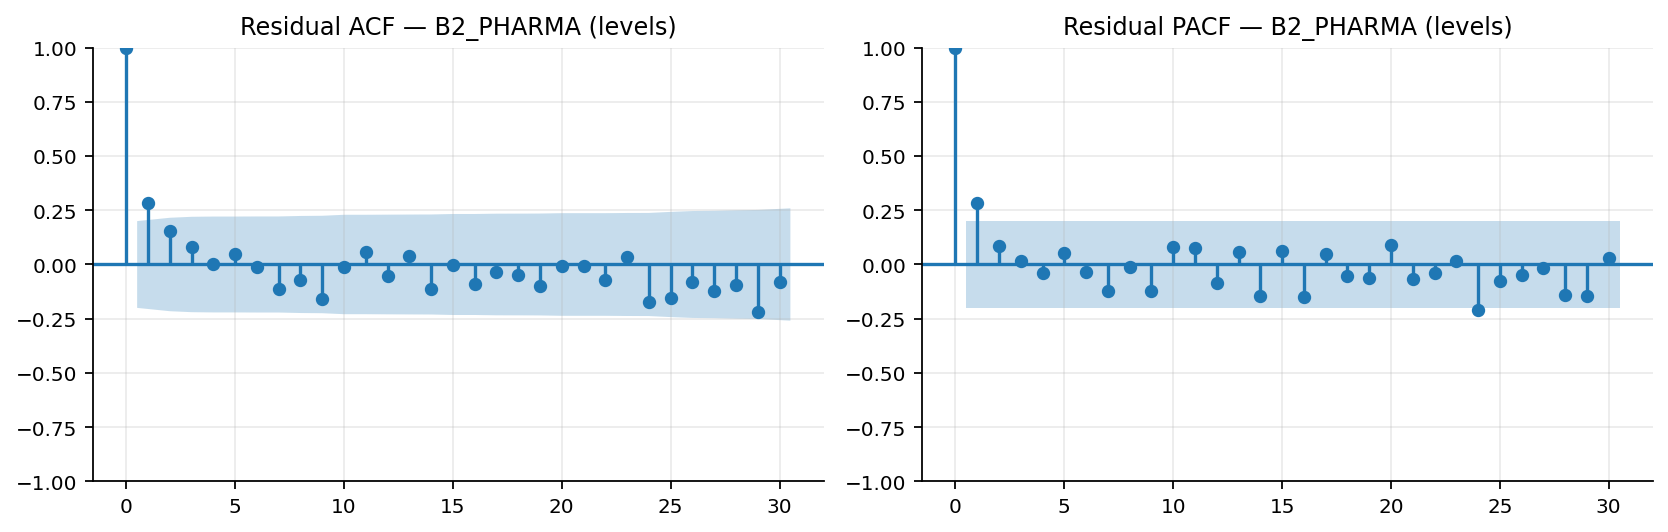

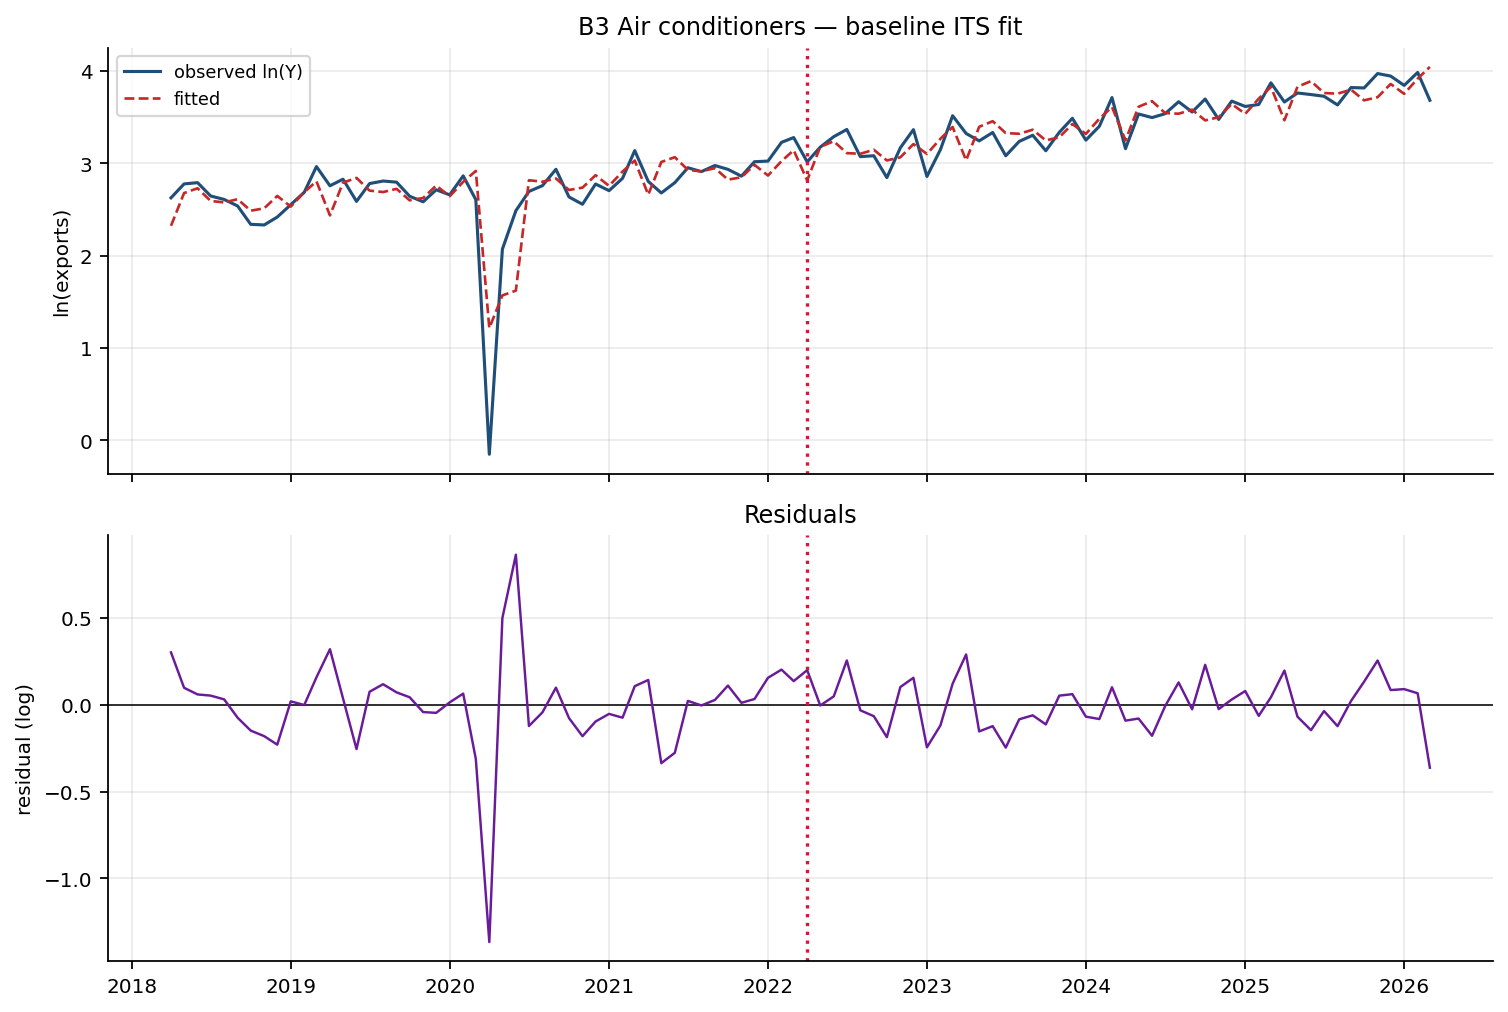

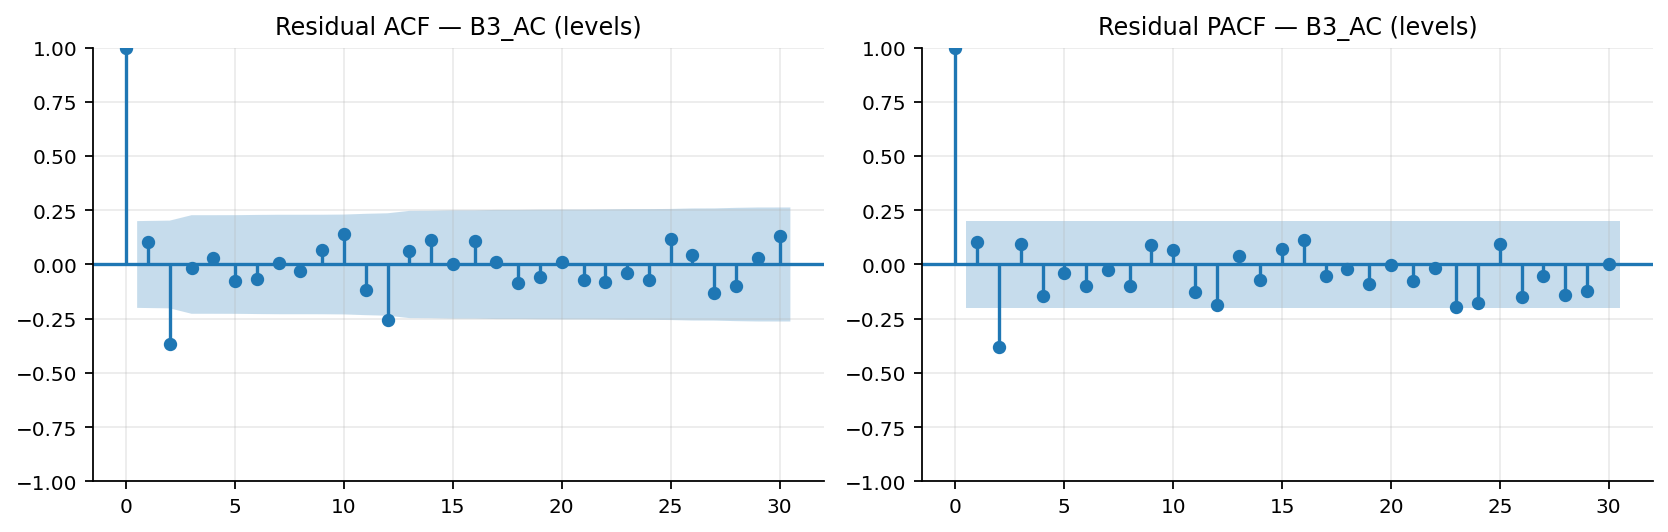

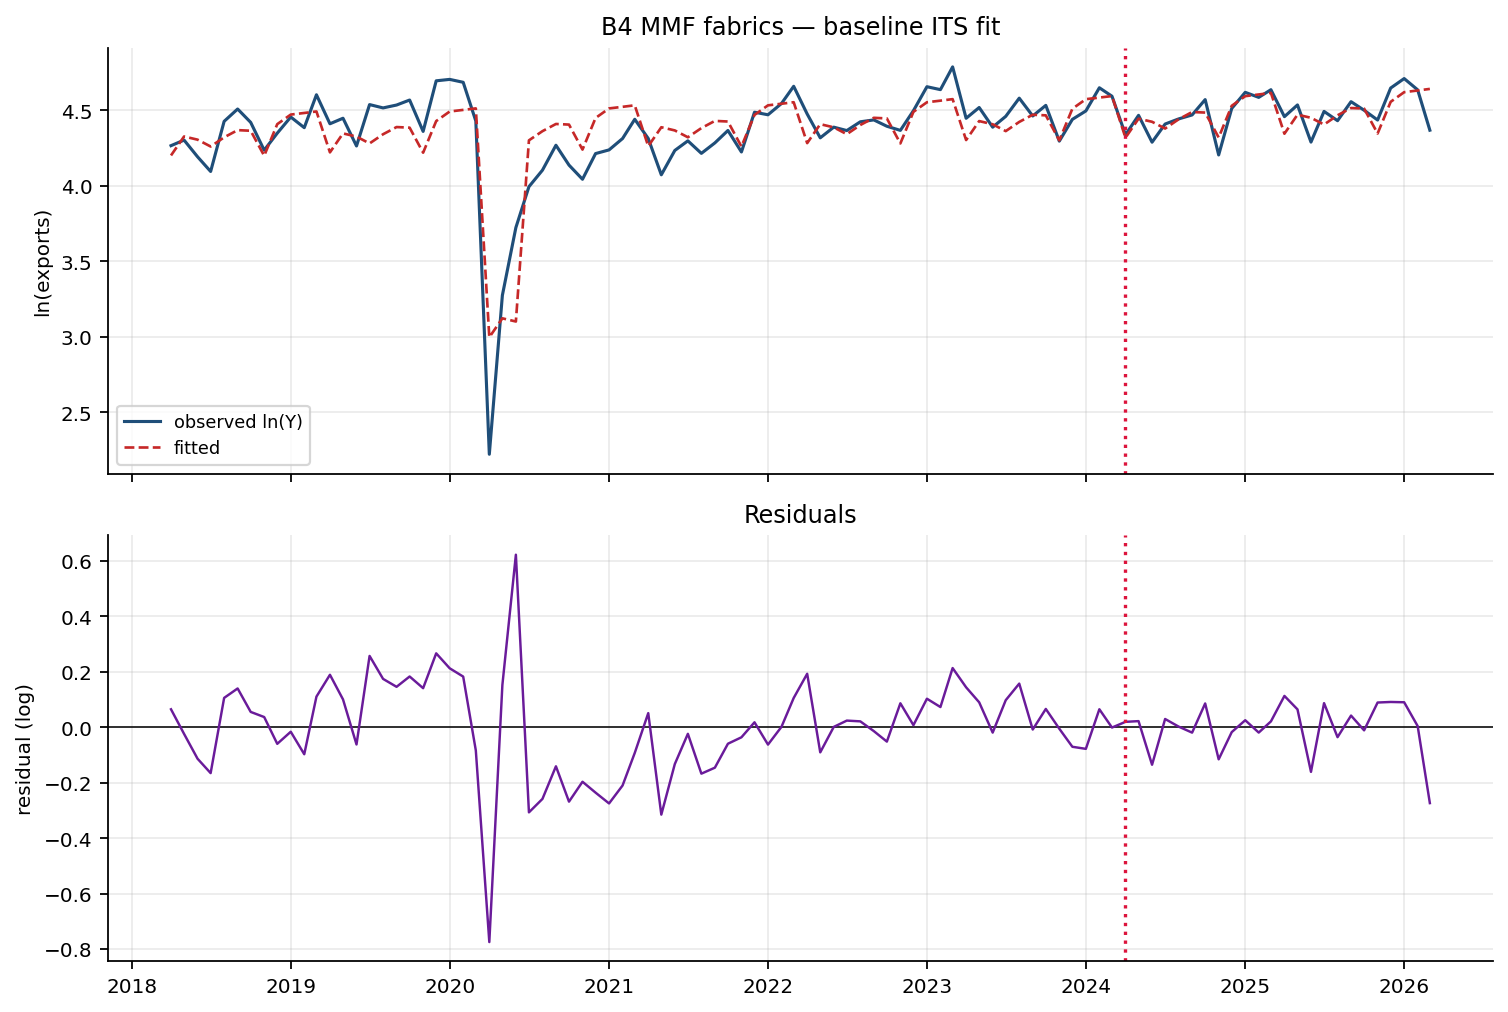

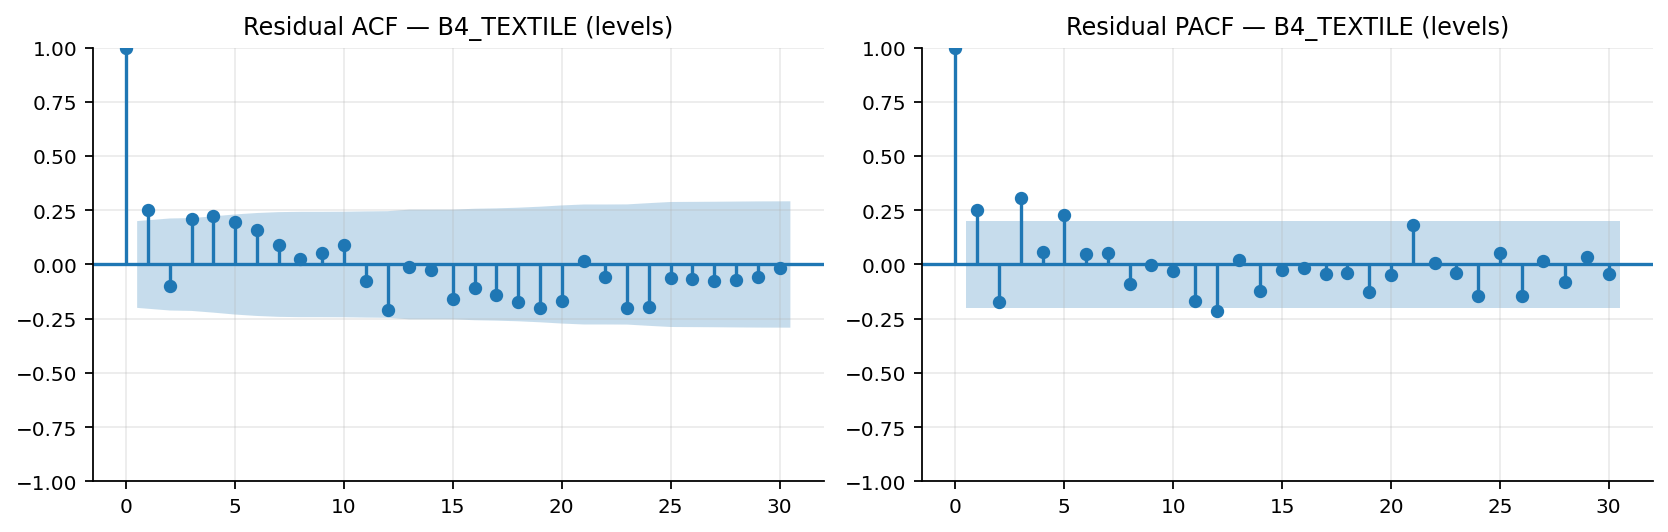

,basket_id,n,r2_adj,beta1_trend,beta2_level,beta3_trendchange,beta3_trendchange_se_hac3,beta3_trendchange_se_hac12,beta3_trendchange_p_hac12,beta3_trendchange_ci95_lo_hac12,beta3_trendchange_ci95_hi_hac12
0,B1_MOBILE,96,0.9199,0.06538,-0.56226,-0.02921,0.01944,0.02020,0.1481,-0.06879,0.01038
1,B2_PHARMA,96,0.8219,0.00765,-0.07524,-0.00134,0.00127,0.00152,0.3785,-0.00431,0.00164
2,B3_AC,96,0.8066,0.00934,0.04325,0.00874,0.00305,0.00272,0.0013,0.00341,0.01407
3,B4_TEXTILE,96,0.6611,0.00170,-0.00494,0.00050,0.00337,0.00233,0.8291,-0.00406,0.00506


In [3]:
keys = {"beta1_trend": "T", "beta2_level": "Post", "beta3_trendchange": "TimeAfter"}
rows, diag, figs = [], [], []
for b in I.TREATED:
    s = I.design(df, b)
    ols, hac = I.fit_baseline(s)
    rows.append(I.coef_row(b, "baseline_levels", ols, hac, keys))
    diag.append(I.diagnostics(b, "baseline_levels", ols))
    figs += [I.plot_fit(s, ols, b), I.plot_resid_diag(ols, b, "levels")]
show(figs)
base = pd.DataFrame(rows)
base[["basket_id","n","r2_adj","beta1_trend","beta2_level","beta3_trendchange",
      "beta3_trendchange_se_hac3","beta3_trendchange_se_hac12",
      "beta3_trendchange_p_hac12","beta3_trendchange_ci95_lo_hac12","beta3_trendchange_ci95_hi_hac12"]]

### 2b. Coefficients in interpretable units

In [4]:
out=[]
for _, r in base.iterrows():
    b1, b3 = r.beta1_trend, r.beta3_trendchange
    out.append(dict(basket_id=r.basket_id,
        pre_trend_lgp_per_month=round(b1*100,3),
        pre_trend_pct_per_year=round(100*(np.exp(b1*12)-1),1),
        beta3_lgp_per_month=round(b3*100,3),
        post_trend_lgp_per_month=round((b1+b3)*100,3),
        post_trend_pct_per_year=round(100*(np.exp((b1+b3)*12)-1),1),
        beta2_level_pct=round(100*(np.exp(r.beta2_level)-1),1),
        beta3_p_hac12=r.beta3_trendchange_p_hac12))
pd.DataFrame(out)

,basket_id,pre_trend_lgp_per_month,pre_trend_pct_per_year,beta3_lgp_per_month,post_trend_lgp_per_month,post_trend_pct_per_year,beta2_level_pct,beta3_p_hac12
0,B1_MOBILE,6.538,119.1,-2.921,3.617,54.3,-43.0,0.1481
1,B2_PHARMA,0.765,9.6,-0.134,0.631,7.9,-7.2,0.3785
2,B3_AC,0.934,11.9,0.874,1.808,24.2,4.4,0.0013
3,B4_TEXTILE,0.170,2.1,0.050,0.220,2.7,-0.5,0.8291


### 2c. Is the HAC correction doing real work?

Ratio of HAC to OLS standard error on β₃. A ratio far from 1 means OLS inference would
have been wrong — in either direction.

In [5]:
pd.DataFrame([dict(basket_id=r.basket_id,
    se_ols=r.beta3_trendchange_se_ols,
    se_hac3=r.beta3_trendchange_se_hac3, ratio_hac3=round(r.beta3_trendchange_se_hac3/r.beta3_trendchange_se_ols,2),
    se_hac12=r.beta3_trendchange_se_hac12, ratio_hac12=round(r.beta3_trendchange_se_hac12/r.beta3_trendchange_se_ols,2))
    for _, r in base.iterrows()])

,basket_id,se_ols,se_hac3,ratio_hac3,se_hac12,ratio_hac12
0,B1_MOBILE,0.00920,0.01944,2.11,0.02020,2.20
1,B2_PHARMA,0.00115,0.00127,1.10,0.00152,1.32
2,B3_AC,0.00360,0.00305,0.85,0.00272,0.76
3,B4_TEXTILE,0.00552,0.00337,0.61,0.00233,0.42


## 3. Residual diagnostics — ACF/PACF, Ljung–Box, Breusch–Godfrey

Figures `its_02_*_resid_levels.png`. The design pre-specified HAC precisely because
residual autocorrelation was expected; these tests establish whether it survives the
month fixed effects.

In [6]:
pd.DataFrame(diag)

,basket_id,model,ljungbox_lag6_p,ljungbox_lag12_p,ljungbox_lag24_p,breusch_godfrey_lag6_p,breusch_godfrey_lag12_p,durbin_watson,adf_resid_p,adf_resid_note,resid_sd_log
0,B1_MOBILE,baseline_levels,0.0000,0.0003,0.0000,0.0003,0.0007,1.057,0.0389,Engle-Granger critical values apply to residua...,0.2977
1,B2_PHARMA,baseline_levels,0.0821,0.1669,0.3771,0.1884,0.4402,1.402,0.0000,Engle-Granger critical values apply to residua...,0.0717
2,B3_AC,baseline_levels,0.0156,0.0066,0.0792,0.0027,0.0141,1.744,0.0000,Engle-Granger critical values apply to residua...,0.2241
3,B4_TEXTILE,baseline_levels,0.0007,0.0020,0.0001,0.0010,0.0025,1.471,0.0121,Engle-Granger critical values apply to residua...,0.1640


## 4. Stationary growth-rate companion

```
g_t = a0 + a1*Post + a2*Break + sum phi_m*Month_m + sum_k delta_k*CovidMonth_k + u
```
`Break = 1{t == T_Ds}` absorbs the differenced level jump, so `a1` is estimated off
`t >= T_Ds + 1` and is the stationary-space analogue of β₃.

In [7]:
gkeys = {"alpha1_postshift": "Post", "alpha2_break": "Break"}
grows, gdiag = [], []
for b in I.TREATED:
    s = I.design(df, b)
    ols, hac = I.fit_growth(s)
    grows.append(I.coef_row(b, "growth_companion", ols, hac, gkeys))
    gdiag.append(I.diagnostics(b, "growth_companion", ols))
    figs.append(I.plot_resid_diag(ols, b, "growth"))
gr = pd.DataFrame(grows)
gr[["basket_id","n","r2_adj","alpha1_postshift","alpha1_postshift_se_hac3",
    "alpha1_postshift_se_hac12","alpha1_postshift_p_hac12","alpha2_break"]]

,basket_id,n,r2_adj,alpha1_postshift,alpha1_postshift_se_hac3,alpha1_postshift_se_hac12,alpha1_postshift_p_hac12,alpha2_break
0,B1_MOBILE,95,0.5493,-4.14776,6.33529,6.22593,0.5053,67.73788
1,B2_PHARMA,95,0.4287,0.52943,1.25450,0.98182,0.5897,4.46471
2,B3_AC,95,0.8522,0.66188,2.49963,1.83176,0.7178,3.30354
3,B4_TEXTILE,95,0.8483,-1.27152,2.10241,1.74751,0.4668,-4.06645


### 4b. The cross-check that matters: β₃ (levels) against α₁ (stationary space)

In [8]:
cc=[]
for (_, rb), (_, rg) in zip(base.iterrows(), gr.iterrows()):
    b3, se3 = rb.beta3_trendchange*100, rb.beta3_trendchange_se_hac12*100
    a1, sea = rg.alpha1_postshift, rg.alpha1_postshift_se_hac12
    cc.append(dict(basket_id=rb.basket_id,
        beta3_lgp=round(b3,3), beta3_se=round(se3,3), beta3_p=rb.beta3_trendchange_p_hac12,
        alpha1_lgp=round(a1,3), alpha1_se=round(sea,3), alpha1_p=rg.alpha1_postshift_p_hac12,
        same_sign=(np.sign(b3)==np.sign(a1)), se_ratio_growth_over_levels=round(sea/se3,2)))
pd.DataFrame(cc)

,basket_id,beta3_lgp,beta3_se,beta3_p,alpha1_lgp,alpha1_se,alpha1_p,same_sign,se_ratio_growth_over_levels
0,B1_MOBILE,-2.921,2.020,0.1481,-4.148,6.226,0.5053,True,3.08
1,B2_PHARMA,-0.134,0.152,0.3785,0.529,0.982,0.5897,False,6.46
2,B3_AC,0.874,0.272,0.0013,0.662,1.832,0.7178,True,6.73
3,B4_TEXTILE,0.050,0.233,0.8291,-1.272,1.748,0.4668,False,7.50


In [9]:
pd.DataFrame(gdiag)

,basket_id,model,ljungbox_lag6_p,ljungbox_lag12_p,ljungbox_lag24_p,breusch_godfrey_lag6_p,breusch_godfrey_lag12_p,durbin_watson,adf_resid_p,adf_resid_note,resid_sd_lgp
0,B1_MOBILE,growth_companion,0.1375,0.0006,0.0001,0.1421,0.0422,2.500,0.0425,Engle-Granger critical values apply to residua...,24.4554
1,B2_PHARMA,growth_companion,0.0062,0.0080,0.0001,0.0003,0.0049,2.800,0.0000,Engle-Granger critical values apply to residua...,7.8171
2,B3_AC,growth_companion,0.1949,0.0631,0.0075,0.0111,0.0106,2.379,0.0000,Engle-Granger critical values apply to residua...,14.3423
3,B4_TEXTILE,growth_companion,0.0032,0.0000,0.0000,0.0000,0.0001,2.739,0.0000,Engle-Granger critical values apply to residua...,10.4899


## 5. Pre-specified B1 `Transition_t` robustness (Jan–Apr 2022)

Declared before estimation in Change Proposal 001. Applied to **B1 only** — no control
basket and no other treated basket had a code change at that boundary.

In [10]:
s = I.design(df, "B1_MOBILE", transition=True)
o0, h0 = I.fit_baseline(s, transition=False)
o1, h1 = I.fit_baseline(s, transition=True)
tk = {**keys, "transition": "Transition"}
tr = pd.DataFrame([I.coef_row("B1_MOBILE", "levels_noTransition", o0, h0, keys),
                   I.coef_row("B1_MOBILE", "levels_withTransition", o1, h1, tk)])
print(f"Transition coef = {o1.params['Transition']:+.5f}  HAC12 se = {h1[12].bse['Transition']:.5f}  "
      f"p = {h1[12].pvalues['Transition']:.4f}")
print(f"beta3 moves by {o1.params['TimeAfter']-o0.params['TimeAfter']:+.6f} "
      f"({100*abs(o1.params['TimeAfter']-o0.params['TimeAfter'])/abs(o0.params['TimeAfter']):.2f}% of the coefficient)")
tr[["model","beta3_trendchange","beta3_trendchange_se_hac12","beta3_trendchange_p_hac12","beta2_level","r2_adj"]]

Transition coef = +0.12678  HAC12 se = 0.11674  p = 0.2775
beta3 moves by +0.000190 (0.65% of the coefficient)


,model,beta3_trendchange,beta3_trendchange_se_hac12,beta3_trendchange_p_hac12,beta2_level,r2_adj
0,levels_noTransition,-0.02921,0.02020,0.1481,-0.56226,0.9199
1,levels_withTransition,-0.02902,0.02023,0.1515,-0.58208,0.9194


## 6. Save preliminary results

In [11]:
base.to_csv("../06_results/ITS_prelim_baseline_levels.csv", index=False)
gr.to_csv("../06_results/ITS_prelim_growth_companion.csv", index=False)
pd.DataFrame(diag + gdiag).to_csv("../06_results/ITS_prelim_diagnostics.csv", index=False)
tr.to_csv("../06_results/ITS_prelim_B1_transition.csv", index=False)
print("4 preliminary result files written;", len(figs), "figures")

4 preliminary result files written; 12 figures


---
## End of Phase 5

Preliminary baseline estimates only — nothing here is final until it survives the
robustness framework in `03_robustness_ITS.ipynb`.